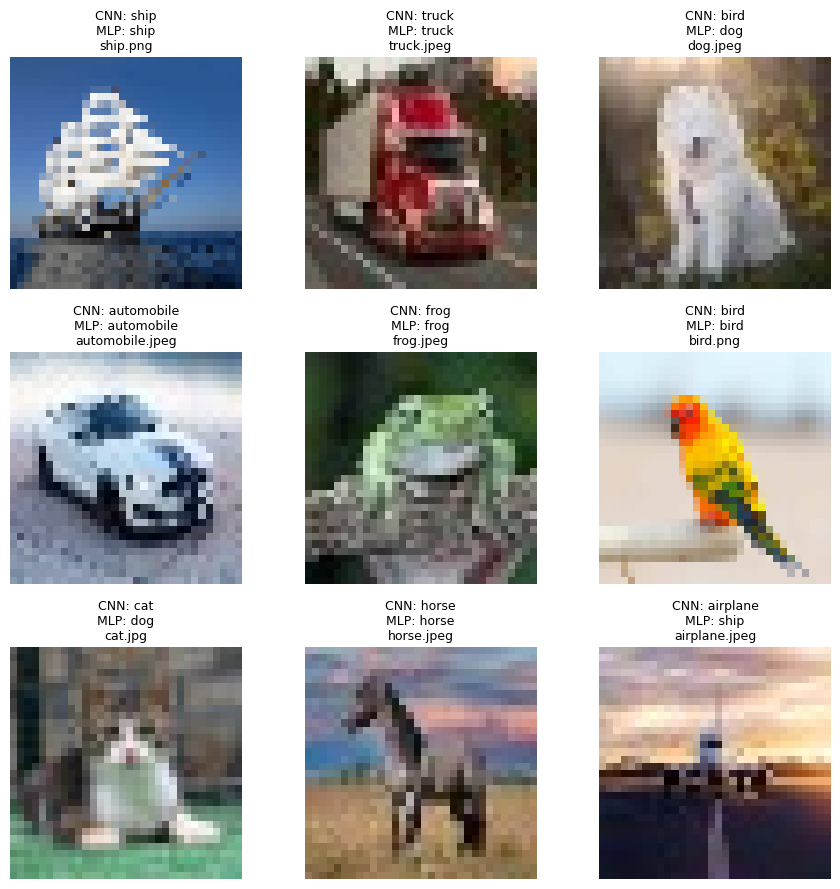

In [ ]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
from PIL import Image
import matplotlib.pyplot as plt
import os

# -----------------------------
# CNN model (your existing CNN model)
# -----------------------------
def create_CNN_model(dropout_rate=0.3):
    model = nn.Sequential(
        nn.Conv2d(3, 32, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2, 2),

        nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2, 2),

        nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2, 2),

        nn.Flatten(),

        nn.Linear(128*4*4, 1024),
        nn.ReLU(),
        nn.Linear(1024, 512),
        nn.ReLU(),

        nn.Dropout(dropout_rate),

        nn.Linear(512, 10)
    )
    return model

# -----------------------------
# Your MLP model function
# -----------------------------
def create_MLP_model(dropout_rate=0.3):
    model = nn.Sequential(
        nn.Flatten(),

        nn.Linear(3072, 512),
        nn.BatchNorm1d(512),
        nn.ReLU(),
        nn.Dropout(dropout_rate),

        nn.Linear(512, 256),
        nn.BatchNorm1d(256),
        nn.ReLU(),
        nn.Dropout(dropout_rate),

        nn.Linear(256, 10)
    )
    return model

# -----------------------------
# CIFAR-10 classes
# -----------------------------
cifar10_classes = ['airplane', 'automobile', 'bird', 'cat', 'deer',
                   'dog', 'frog', 'horse', 'ship', 'truck']

# -----------------------------
# Transform
# -----------------------------
transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2023, 0.1994, 0.2010))
])

# -----------------------------
# Load models
# -----------------------------
device = torch.device('cpu')

cnn_model = create_CNN_model()
cnn_model.load_state_dict(torch.load("CNN_model.pth", map_location=device))
cnn_model.eval()

mlp_model = create_MLP_model()
mlp_model.load_state_dict(torch.load("MLP_model.pth", map_location=device))
mlp_model.eval()

# -----------------------------
# Load and predict images
# -----------------------------
img_folder = './image'  # Your image folder path
img_files = [f for f in os.listdir(img_folder) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

images = []
cnn_predictions = []
mlp_predictions = []

for fname in img_files:
    path = os.path.join(img_folder, fname)
    img = Image.open(path).convert('RGB')
    images.append((img.copy(), fname))

    input_tensor = transform(img).unsqueeze(0)  # shape: [1, 3, 32, 32]

    with torch.no_grad():
        cnn_out = cnn_model(input_tensor)
        _, cnn_pred = torch.max(cnn_out, 1)

        mlp_out = mlp_model(input_tensor)
        _, mlp_pred = torch.max(mlp_out, 1)

        cnn_predictions.append(cnn_pred.item())
        mlp_predictions.append(mlp_pred.item())

# -----------------------------
# Plot results
# -----------------------------
cols = 3
rows = (len(images) + cols - 1) // cols
plt.figure(figsize=(9, rows * 3))

for idx, ((img, fname), cnn_pred, mlp_pred) in enumerate(zip(images, cnn_predictions, mlp_predictions)):
    plt.subplot(rows, cols, idx + 1)
    plt.imshow(img)
    plt.title(f"CNN: {cifar10_classes[cnn_pred]}\nMLP: {cifar10_classes[mlp_pred]}\n{fname}", fontsize=9)
    plt.axis('off')

plt.tight_layout()
plt.show()
